# Stage 6o - Figure 7 v2: the MESM CO$_2$-only optimization, redone

Companion notebook for `scripts/6o_fig7_MESM_opt_seed_sweep.py` and
`scripts/6o_fig7_MESM_opt_evaluate.py`. Those run on the cluster; this only
loads their collected cache and plots it.

**What this reproduces.** Figure 7's panels (a)/(b) in the main text are the
CO$_2$ emissions trajectory produced by the inverse optimization against the
MESM-calibrated SCM, and the temperature response it drives. This is that same
experiment ("Opt. All"), re-run with every update from the revisions:

| | original Figure 7 | this rerun |
|---|---|---|
| SCM calibration | `mode='MESM'`, ECS 3.568 K | `mode='MESM_tier1'`, ECS 3.205 K (MESM's measured value) |
| optimizer hyperparameters | hand-set (`step_size=5000`, `lr_inner=0.05`, `wd_inner=0.01`) | Stage 0b `best_config_unified.json` |
| baseline emulator | hardcoded `K=400, lr=0.05, wd=0.01` | Stage 6e `best_baseline_config_K400.json` |
| outer iterations | 1000 | 2000 |
| seeds | 1 (deterministic) | 50 |
| initial conditions | `sine` | `constant`, `sine`, `gaussian` |

150 runs in total. See `MESM_SCM_CALIBRATION.md` for how the new calibration was
derived.

**Two things to keep straight when writing the caption.**

1. The $\overline{\Delta T}(t)$ curves here come from the **MESM-calibrated SCM**,
   not from a real MESM ensemble run. The original panels used actual MESM
   output (`data/MESM/emis_driven/zonal_data/optimized/`), which exists only for
   the two original fixed trajectories; no MESM runs exist for these
   newly-optimized ones.
2. The percentile lines are **whole trajectories from real seeds**, picked by
   each seed's average skill across all scenarios - not a pointwise percentile
   across 50 trajectories, which would be a curve no optimization ever produced
   and not even a valid emissions pathway.

In [1]:
import os, sys, pickle
sys.path.insert(0, ".")

import numpy as np
import utils_inverse
import utils_plotting
import utils_FaIR_JAX

CACHE = utils_inverse.FIG7V2_CACHE_PATH
print("cache:", CACHE)

data = utils_inverse.load_fig7_v2_data(cache_path=CACHE)
print("initial conditions:", list(data["selection"]))
print("seeds per IC:", {ic: len(v) for ic, v in data["scores"].items()})

cache: data/SI_results/seed_uncertainty/fig7v2_seed_spread_MESM_tier1.pkl
initial conditions: ['constant', 'sine', 'gaussian']
seeds per IC: {'constant': 50, 'sine': 50, 'gaussian': 50}


## 1. The SCM this was optimized against

`mode='MESM_tier1'` selects `utils_FaIR_JAX.MESM_TIER1_PARAMS`. Printed here so
the notebook records which calibration produced these results rather than
leaving it implicit in a script constant.

In [2]:
for name in ["MESM", "MESM_tier1"]:
    p = utils_FaIR_JAX.params_for_mode(name)
    ecs = 3.7748 * float(np.sum(np.asarray(p["q"])))
    print(f"{name:12s} d={np.asarray(p['d']).round(3)}  "
          f"q={np.asarray(p['q']).round(4)}  ECS={ecs:.3f} K")
print("\nMESM's own measured ECS: 3.205 K")

MESM         d=[  0.606  16.034 277.607]  q=[0.2128 0.2658 0.4667]  ECS=3.568 K
MESM_tier1   d=[ 0.533 70.099 89.463]  q=[0.2417 0.292  0.3153]  ECS=3.205 K

MESM's own measured ECS: 3.205 K


## 2. Seed ranking and the 25th / 50th / 75th percentile pick

Each seed's "average skill over all scenarios" is the weighted overall NRMSE,
Tier 1:7 / Tier 2:5 / DECK:2 / CS3:2 - the same weighting used by
`4c_MESM_baseline_hp_search.py`, `6l_fig7_scalar_config_swap.py` and
`6m_fig7_seed_selection_variants.ipynb`. Lower is better, so the 25th
percentile is a *good* seed and the 75th a poor one.

In [3]:
for ic, sel in data["selection"].items():
    s = data["scores"][ic]
    vals = np.array([s[k] for k in sorted(s)])
    print(f"--- {ic} (n={len(vals)}) ---")
    print(f"    distribution: median {np.median(vals):.4f} "
          f"IQR [{np.percentile(vals,25):.4f}, {np.percentile(vals,75):.4f}]  "
          f"min {vals.min():.4f}  max {vals.max():.4f}")
    for q in (25, 50, 75):
        print(f"    p{q}: seed {sel[q]:3d}  weighted NRMSE {s[sel[q]]:.4f}  "
              f"(target {np.percentile(vals, q):.4f})")

--- constant (n=50) ---
    distribution: median 0.0393 IQR [0.0372, 0.0417]  min 0.0327  max 0.0477
    p25: seed   0  weighted NRMSE 0.0371  (target 0.0372)
    p50: seed   1  weighted NRMSE 0.0395  (target 0.0393)
    p75: seed  49  weighted NRMSE 0.0417  (target 0.0417)
--- sine (n=50) ---
    distribution: median 0.0396 IQR [0.0370, 0.0415]  min 0.0350  max 0.0565
    p25: seed  15  weighted NRMSE 0.0369  (target 0.0370)
    p50: seed  37  weighted NRMSE 0.0396  (target 0.0396)
    p75: seed  21  weighted NRMSE 0.0417  (target 0.0415)
--- gaussian (n=50) ---
    distribution: median 0.0401 IQR [0.0378, 0.0431]  min 0.0339  max 0.1388
    p25: seed  47  weighted NRMSE 0.0377  (target 0.0378)
    p50: seed  38  weighted NRMSE 0.0401  (target 0.0401)
    p75: seed   3  weighted NRMSE 0.0432  (target 0.0431)


In [4]:
# How the optimized emulator compares to the baseline, per IC.
with open(CACHE, "rb") as f:
    cache = pickle.load(f)

W = {"Tier 1": 7, "Tier 2": 5, "DECK": 2, "CS3": 2}
print(f"{'IC':10s} {'optimized (median [IQR])':32s} {'baseline (median [IQR])':32s} beats baseline")
for ic in utils_inverse.FIG7V2_INIT_CONDS:
    e = cache[ic]
    seeds = sorted(e)
    opt = np.array([e[s]["weighted_optimal"] for s in seeds])
    bse = np.array([e[s]["weighted_baseline"] for s in seeds])
    fo = f"{np.median(opt):.4f} [{np.percentile(opt,25):.4f}, {np.percentile(opt,75):.4f}]"
    fb = f"{np.median(bse):.4f} [{np.percentile(bse,25):.4f}, {np.percentile(bse,75):.4f}]"
    print(f"{ic:10s} {fo:32s} {fb:32s} {int((opt < bse).sum())}/{len(seeds)}")

IC         optimized (median [IQR])         baseline (median [IQR])          beats baseline
constant   0.0393 [0.0372, 0.0417]          0.0601 [0.0565, 0.0635]          50/50
sine       0.0396 [0.0370, 0.0415]          0.0601 [0.0565, 0.0635]          50/50
gaussian   0.0401 [0.0378, 0.0431]          0.0601 [0.0565, 0.0635]          48/50


## 3. Convergence over the 2000 outer updates

Median and IQR across the 50 seeds, per initial condition, against the baseline
emulator's own seed spread on the same SCM. This is the in-sample bilevel
objective - the NRMSE the optimizer itself is descending, over the scenarios
being optimized against - so it is a training curve, not held-out skill. The
weighted comparison in section 2 is the out-of-sample counterpart.

The curves are penalty-corrected (`recover_nrmse_trajectory`): a checkpoint's
raw `errors` is NRMSE + `smoothness_weight` * $\sum (\Delta U)^2$, and the
correction is applied per-checkpoint using the `smoothness_weight` each one
records in its own meta.

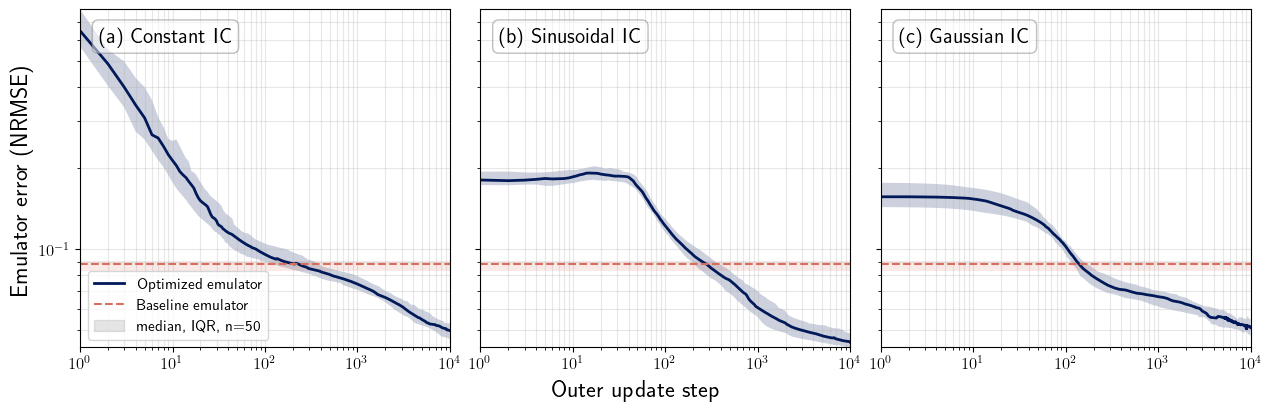

In [5]:
utils_plotting.plot_ic_convergence_seed_spread(
    **data["convergence_kwargs"], save=True, figname="fig07_v2_convergence",
)

## 4. Figure 7 v2

Panels (a)/(b)/(c): constant, sinusoidal and Gaussian initial conditions. Each
shows the 25th/50th/75th-percentile seed's optimized emissions (left axis,
solid) and the SCM temperature response it produces (right axis, dashed). The
median seed is the heavy line; the quartile seeds are lighter.

Panel (d) is a **placeholder** for the per-scenario NRMSE bar chart, drawn empty
so the figure's proportions match the original Figure 7 while that panel's data
source is settled. Pass `placeholder_bar_panel=False` for a clean three-panel
version.

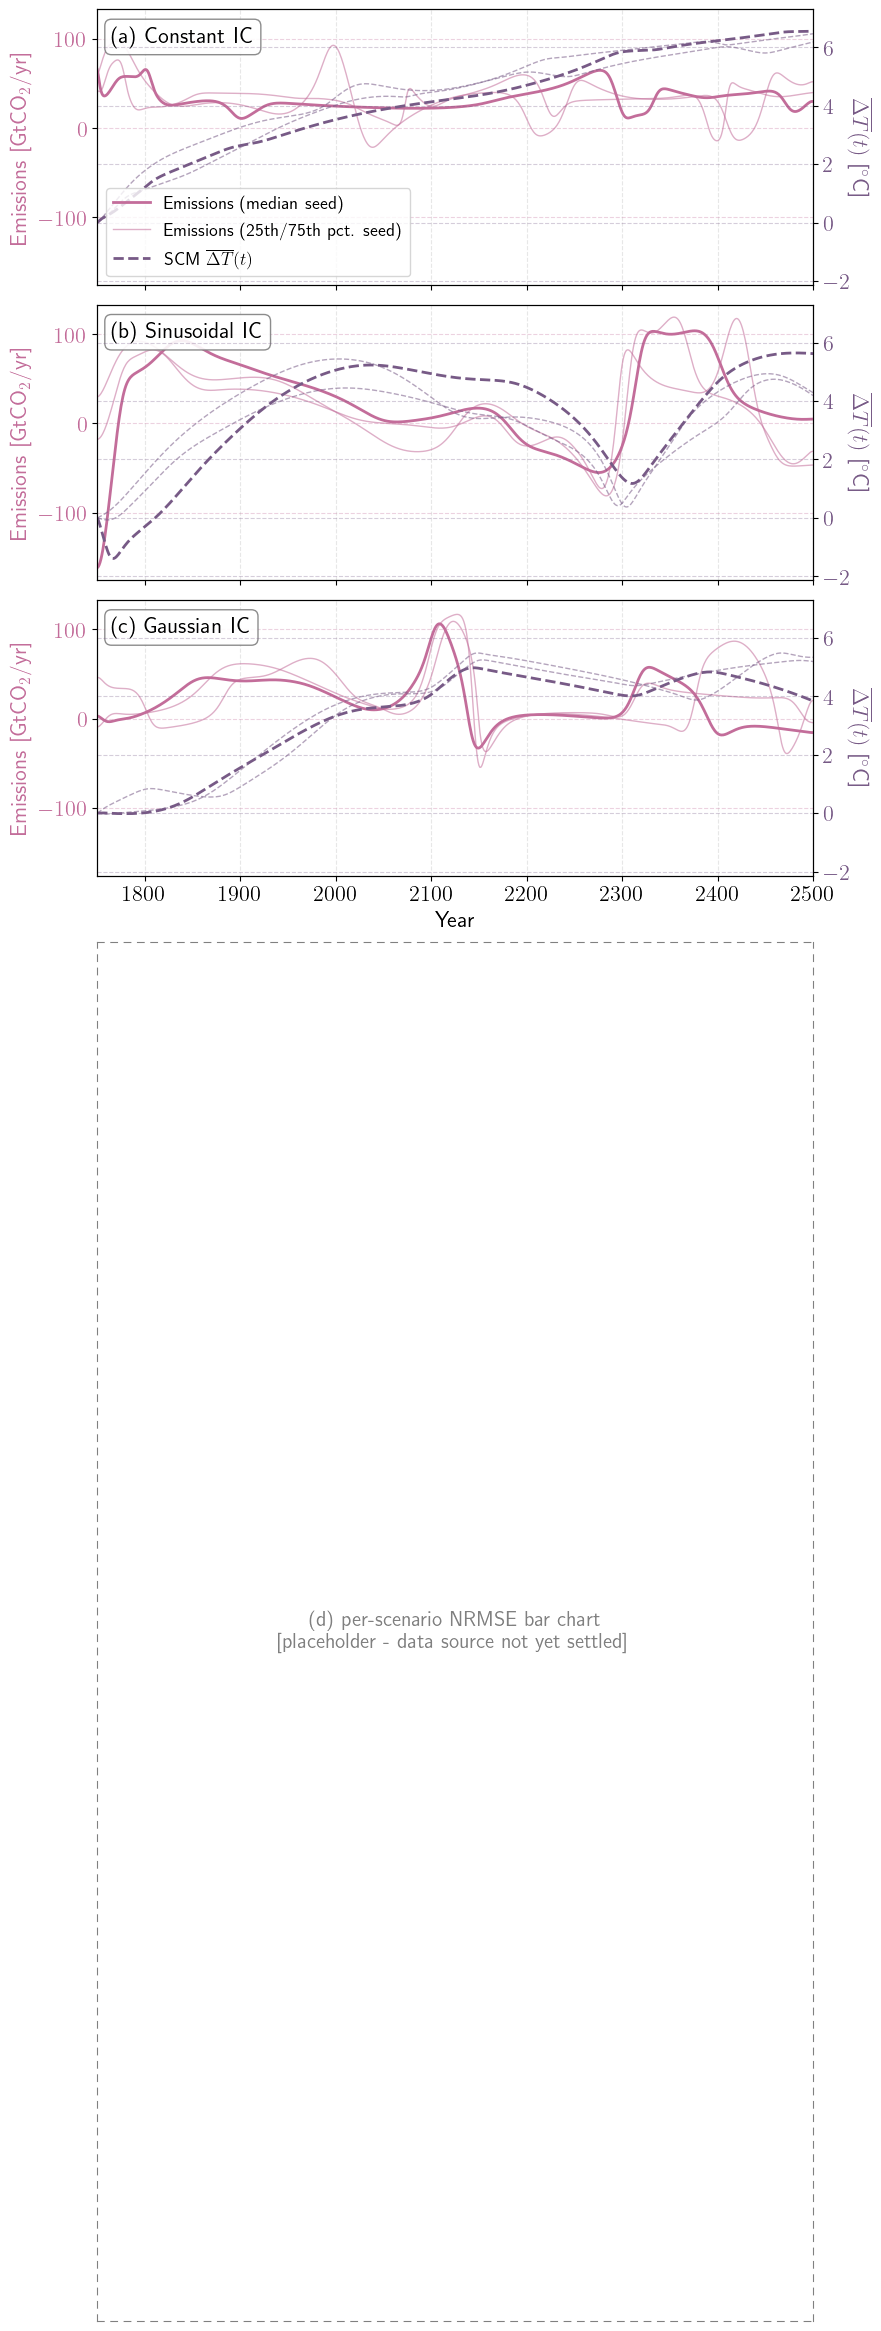

In [6]:
utils_plotting.plot_fig7_v2_ic_panels(
    **data["panels_kwargs"], save=True, figname="fig07_v2_ic_panels",
)

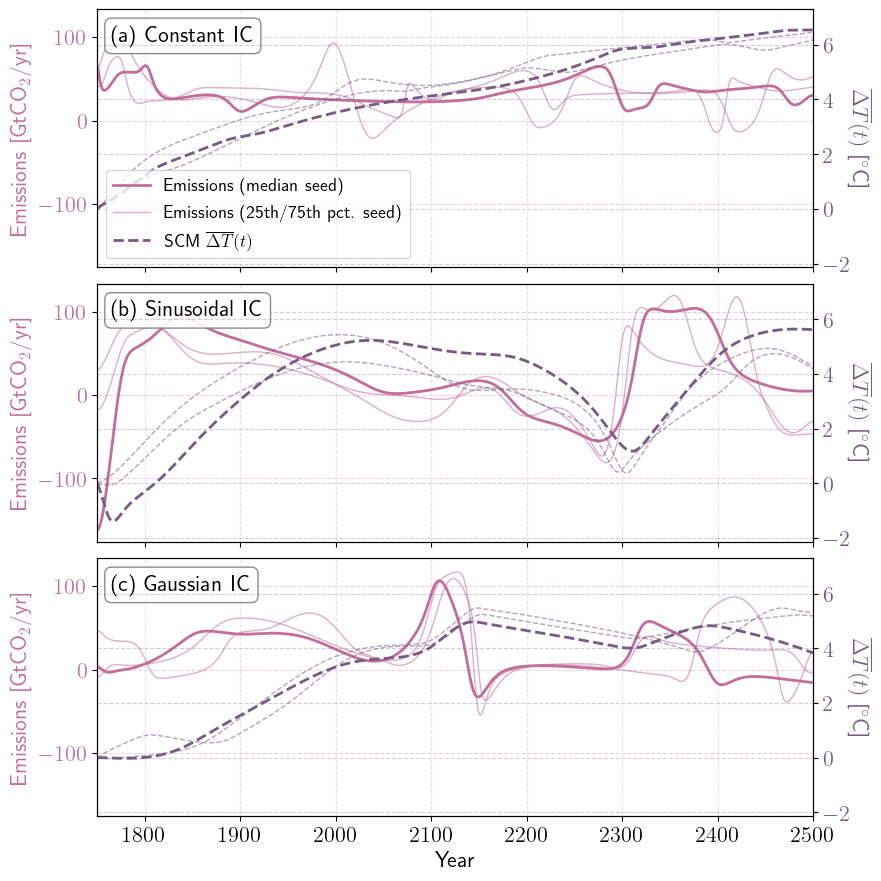

In [7]:
# Three-panel version, no placeholder.
utils_plotting.plot_fig7_v2_ic_panels(
    **data["panels_kwargs"], save=True, placeholder_bar_panel=False,
    figname="fig07_v2_ic_panels_nobar",
)